In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv("https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/main/day25-normalization/wine_data.csv", header=None, usecols=[0,1,2])
df.columns=["Class Label", "Alcohol", "Malic Acid"]

In [10]:
df

,Class Label,Alcohol,Malic Acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

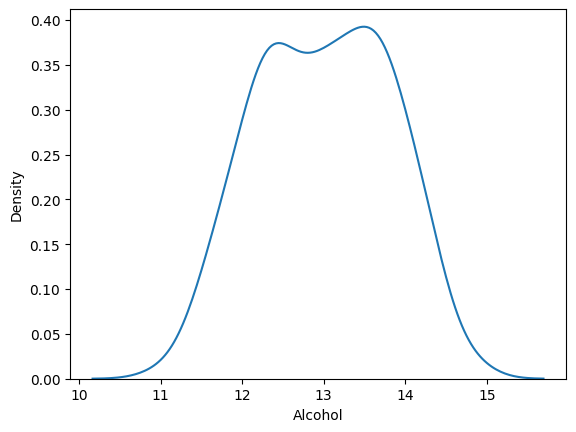

In [13]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

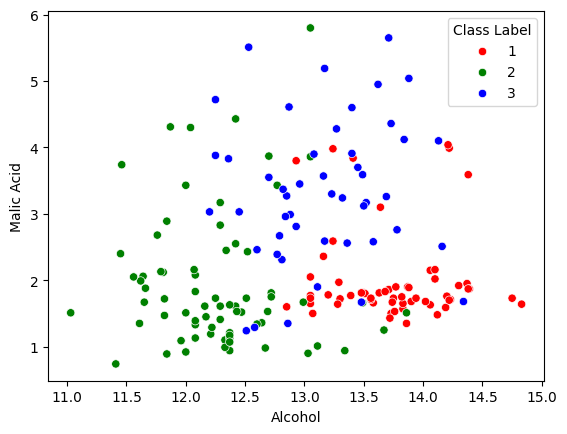

In [14]:
color_dict = {1:'red', 2:'green', 3:'blue'}
sns.scatterplot(data=df, x='Alcohol', y='Malic Acid', hue='Class Label', palette=color_dict)
#

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Class Label', axis=1), df['Class Label'], test_size=0.2, random_state=0)

X_train.shape, X_test.shape


((142, 2), (36, 2))

In [16]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [20]:
np.round(X_train.describe(), 1)

,Alcohol,Malic Acid
count,142.0,142.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.7
25%,12.3,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [21]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic Acid
count,142.0,142.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


<Axes: ylabel='Alcohol'>

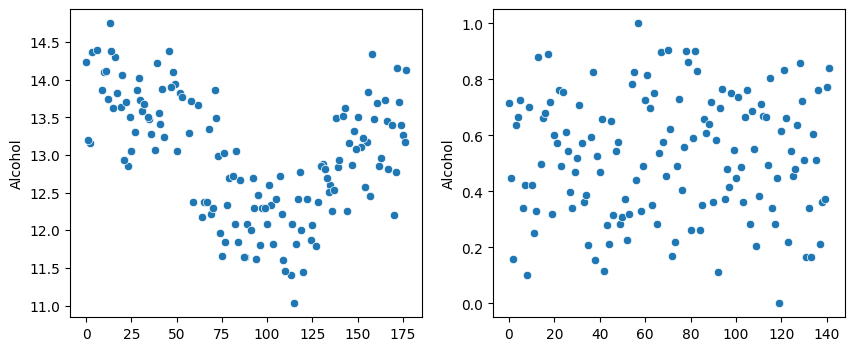

In [23]:
fif, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10,4))
sns.scatterplot(X_train['Alcohol'], ax=ax1)
sns.scatterplot(X_train_scaled['Alcohol'], ax=ax2)


<Axes: xlabel='Malic Acid', ylabel='Density'>

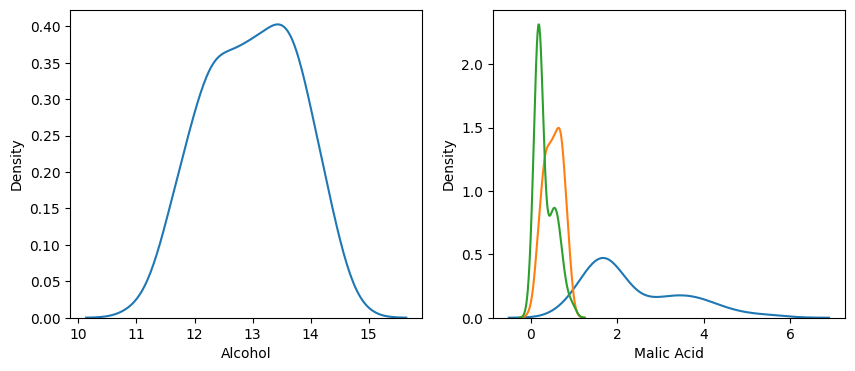

In [24]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10,4))

sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic Acid'], ax=ax2)
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Malic Acid'], ax=ax2)

<Axes: xlabel='Malic Acid', ylabel='Density'>

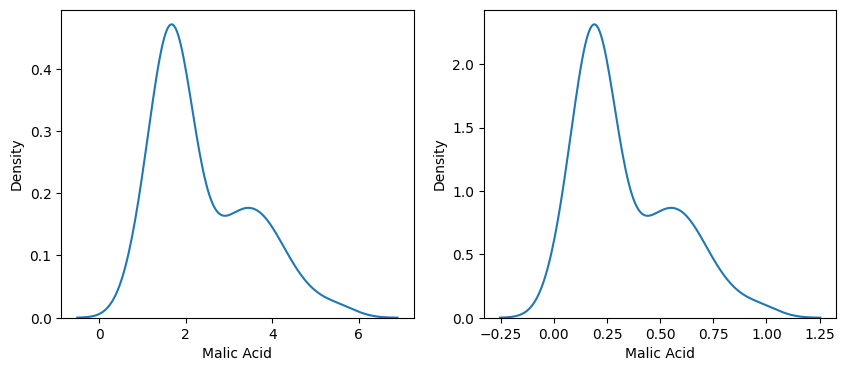

In [25]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10,4))

sns.kdeplot(X_train['Malic Acid'], ax=ax1)
sns.kdeplot(X_train_scaled['Malic Acid'], ax=ax2)